In [83]:
# Step 2: EEG decoding


# GAO decoding analysis
# 
import pandas as pd
import glob
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, roc_auc_score
import scipy.stats as stats
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed
from sklearn.base import clone
from mne.time_frequency import tfr_array_morlet
import pingouin as pg
from sklearn.utils import shuffle
from collections import defaultdict

from utils.gao_functions import red_color, blue_color, red_palette, blue_palette, purple_color, purple_palette, lightblue_color, lightred_color, lightblue_palette, lightred_palette, calculate_vtc, calculate_BF, plot_BF_subplot, get_image_cat, calculate_COCE_zone, make_timecourse_plot, make_Gabor_timecourse_plot

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# import numpy as np
# from scipy.io import loadmat
# import pandas as pd
import os
os.environ["R_HOME"] = r"/Library/Frameworks/R.framework/Resources"

from rpy2.robjects import r
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
import matplotlib.pyplot as plt
import seaborn as sns

bf_package=importr('BayesFactor')


# rus = RandomUnderSampler(random_state=42)

import matplotlib.pyplot as plt
from matplotlib import colors

import mne
# from mne.datasets import sample
from mne.decoding import (
    SlidingEstimator
)

# clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced'), )

clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(store_covariance=True))
experiment_name = 'GAO'


from included_subs import subs

# CHECK UD/LR MAPPING _ DO NAMES MATCH NUMBERS?
dot_direction_map = {'UD':41, 'LR':42}
cat_map = {'vehicle':31, 'food': 32}

train_image_triggers = [11, 12] #vehicle, food
train_gabor_triggers = [21, 22] #Vertical, horizontal

test_image_triggers = [31, 32]# vehicle, food
test_gabor_triggers = [41, 42]# Vertical, horizontal

# smooth_VTC = 'yes'
# if smooth_VTC == 'yes':
#     vtc_variable = 'vtc_smooth_detrended'
# elif smooth_VTC == 'no':
#     vtc_variable = 'vtc_detrended'
# else:
#     print('smooth_VTC must be either yes or no!')
font_sz = 18
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.labelsize'] = font_sz
plt.rcParams['ytick.labelsize'] = font_sz
plt.rcParams['axes.titlesize'] = font_sz
plt.rcParams['legend.fontsize'] = font_sz - 4

figdir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/output/figures/'

exclude_ppt_channels = 'yes'
exclude_channels = {
    '01':['TP9','Fp1','Fp2','P3'],
    '02':['CP6','T7','TP9','Fp1','Fp2'],
    '03':['F4','TP9','Fp1','Fp2'],
    '04':['TP9','Fp1','Fp2'],
    '05':['FC5','TP9','Fp1','Fp2'],
    '06':['TP9','Fp1','Fp2'],
    '07':['TP9','Fp1','Fp2'],
    '08':['T8', 'CP2', 'FT9', 'T7', 'TP9','Fp1','Fp2'],
    '09':['TP9','Fp1','Fp2'],
    '10':['T8', 'TP9','Fp1','Fp2'],
    '11':['C3', 'TP9','Fp1','Fp2'],
    '12':['TP9','Fp1','Fp2'],
    '13':['TP9','Fp1','Fp2'],
    '14':['T7','T8','FC2','P7','Cz','CP2', 'TP9','Fp1','Fp2'],
    '15':['TP9','Fp1','Fp2'],
    '16':['TP9','Fp1','Fp2'],
    '17':['TP9','Fp1','Fp2','T7','T8'],
    '18':['TP9','Fp1','Fp2','C4','FC1'],
    '19':['TP9','Fp1','Fp2','FT10','FT9','T7','FC6'],
    '20':['TP9','Fp1','Fp2'],
    '21':['TP9','Fp1','Fp2','F3','F4','T7'],
    '22':['TP9','Fp1','Fp2','FT10'],
    '23':['TP9','Fp1','Fp2'],
    '24':['TP9','Fp1','Fp2','FT10'],
    '25':['TP9','Fp1','Fp2','T7'],
    '26':['TP9','Fp1','Fp2'],
    '27':['TP9','Fp1','Fp2'],
    '28':['TP9','Fp1','Fp2','F3'],
    '29':['TP9','Fp1','Fp2','T8']
}


cacs_montage = mne.channels.read_custom_montage('/Users/annacorriveau/Downloads/actiCap_snap_CACS_CAS/actiCap_slim_for actiChamp_Plus/CACS-32/CACS-32_NO_REF.bvef')
# print(cacs_montage.ch_names)
all_channels = cacs_montage.ch_names
# all_channels.remove('GND')
# print(all_channels)

In [93]:
def repeated_parallel_balanced_classification(subs, DF_x_test_image_inzone, DF_x_test_image_outzone, DF_y_test_image_inzone, DF_y_test_image_outzone, image_decoder, epochs, nIter):
    BF_mean_list = []
    T_list =[]
    mean_auc_in_all = pd.DataFrame()
    mean_auc_out_all = pd.DataFrame()
    for ii in np.arange(0, nIter):
        print(ii)
        auc_all = pd.DataFrame()
        auc_out_all = pd.DataFrame()

        mean_in_pred = []
        mean_out_pred = []
        for sub in subs:
        # print(sub)
            min_trials = np.min([DF_x_test_image_inzone[sub].shape[0], DF_x_test_image_outzone[sub].shape[0]])

            DF_x_test_image_inzone_shuffle, DF_y_test_image_inzone_shuffle = shuffle(DF_x_test_image_inzone[sub], DF_y_test_image_inzone[sub], random_state=ii)
            DF_x_test_image_outzone_shuffle, DF_y_test_image_outzone_shuffle = shuffle(DF_x_test_image_outzone[sub], DF_y_test_image_outzone[sub], random_state=ii+1)

            DF_x_test_image_inzone_shuffle_subset = DF_x_test_image_inzone_shuffle[0:min_trials]
            DF_y_test_image_inzone_shuffle_subset = DF_y_test_image_inzone_shuffle[0:min_trials]
            DF_x_test_image_outzone_shuffle_subset = DF_x_test_image_outzone_shuffle[0:min_trials]
            DF_y_test_image_outzone_shuffle_subset = DF_y_test_image_outzone_shuffle[0:min_trials]


            
            y_pproba_image_inzone = image_decoder[sub].predict_proba(DF_x_test_image_inzone_shuffle_subset)
            auc_image_inzone = [roc_auc_score(DF_y_test_image_inzone_shuffle_subset, y_pproba_image_inzone[:,col,1]) for col in np.arange(0,y_pproba_image_inzone.shape[1])]
            auc_image_inzone_trial= np.array(auc_image_inzone)[epochs.times>0]
            auc_all = pd.concat([auc_all, pd.DataFrame(auc_image_inzone).T], axis=0)
            mean_in_pred.append(np.mean(auc_image_inzone_trial))


            y_pproba_image_outzone = image_decoder[sub].predict_proba(DF_x_test_image_outzone_shuffle_subset)
            auc_image_outzone = [roc_auc_score(DF_y_test_image_outzone_shuffle_subset, y_pproba_image_outzone[:,col,1]) for col in np.arange(0,y_pproba_image_outzone.shape[1])]
            auc_image_outzone_trial= np.array(auc_image_outzone)[epochs.times>0]
            auc_out_all = pd.concat([auc_out_all, pd.DataFrame(auc_image_outzone).T], axis=0)
            mean_out_pred.append(np.mean(auc_image_outzone_trial))

        # BF = calculate_BF(auc_all, auc_out_all)
        # BF_mean = np.mean(np.array(BF)[epochs.times>0])
        # BF_mean_list.append(BF_mean)
        tstat = float(pg.ttest(mean_in_pred, mean_out_pred, paired=True)['T'].values[0])
        T_list.append(tstat)
        bf10 = float(pg.ttest(mean_in_pred, mean_out_pred, paired=True)['BF10'].values[0])
        BF_mean_list.append(bf10)
        mean_auc_in_all = pd.concat([mean_auc_in_all, pd.DataFrame(np.mean(auc_all, axis=0)).T], axis=0)
        mean_auc_out_all = pd.concat([mean_auc_out_all, pd.DataFrame(np.mean(auc_out_all, axis=0)).T], axis=0)

    return BF_mean_list, T_list, mean_auc_in_all, mean_auc_out_all

def parallelize(subs, DF_x_test_image_inzone, DF_x_test_image_outzone, DF_y_test_image_inzone, DF_y_test_image_outzone, image_decoder, epochs, nIter, n_jobs=-1):
    """
    Run classification multiple times in parallel and average predictions.
    """
    par_out = Parallel(n_jobs=n_jobs)(
        delayed(repeated_parallel_balanced_classification)(subs, DF_x_test_image_inzone, DF_x_test_image_outzone, DF_y_test_image_inzone, DF_y_test_image_outzone, image_decoder, epochs, nIter)
        for i in range(1)
    )
    results, t_list, mean_auc_in_all, mean_auc_out_all = par_out[0]
    return results, t_list, mean_auc_in_all, mean_auc_out_all

In [90]:

mean_in_pred = [20, 10, 10, 14, 15, 16, 17, 20]
mean_out_pred = [10, 8, 9, 5, 6, 7, 8, 8]

t = pg.ttest( mean_out_pred,mean_in_pred,  paired=True)
print(t)

bf10 = float(pg.ttest(mean_in_pred, mean_out_pred, paired=True)['BF10'].values[0])


               T  dof alternative     p-val            CI95%   cohen-d  \
T-test -5.493808    7   two-sided  0.000913  [-10.91, -4.34]  2.568563   

          BF10     power  
T-test  44.413  0.999982  


In [8]:
# Use performance on infrequent trials as label for in-zone vs out-of-zone
nIter = 1

FWHM = 4

DF_x_train_image = defaultdict()
DF_x_test_image_inzone = defaultdict()
DF_x_test_image_outzone = defaultdict()

DF_y_train_image = defaultdict()
DF_y_test_image_inzone = defaultdict()
DF_y_test_image_outzone = defaultdict()

DF_x_train_gabor = defaultdict()
DF_x_test_gabor_inzone = defaultdict()
DF_x_test_gabor_outzone = defaultdict()

DF_y_train_gabor = defaultdict()
DF_y_test_gabor_inzone = defaultdict()
DF_y_test_gabor_outzone = defaultdict()

in_count = []
out_count = []

for sub in subs:
    print(sub)
    behav_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/' + sub + '/'
    # eeg_dir = '/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'
    eeg_dir = '/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-' + sub + '/eeg/'

    behav_files = glob.glob(behav_dir + sub + '*.csv')
    print(behav_files)
    if len(behav_files)==1:
        behav_file = pd.read_csv(behav_files[0])
    else:
        print('Multiple (or zero) behavioral files found for subject ' + sub)

    behav_file = behav_file[behav_file['task'].notna()]
    behav_file = behav_file[~behav_file['task'].str.contains('practice')]
    dot_training_trials = behav_file[behav_file['task']=='train_dots']
    cat_training_trials = behav_file[behav_file['task']=='train_image_cat']

    cpt_trials = behav_file[behav_file['task'].str.contains('cpt')]

    # print(cpt_trials.task)
    cpt_trials_vtc = calculate_COCE_zone(cpt_trials, FWHM)

    behav_join_DF = pd.merge(behav_file, cpt_trials_vtc, left_index=True, right_index=True, how='outer')
    # behav_join_DF.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_behav_DF_withVTC.csv')
    cpt_trials_vtc.to_csv('/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/behavioral_data_withVTC/' + sub + '/' + sub + '_CPT_DF_withVTC_andCOCE.csv')


    # # Compare performance in and out of the zone
    # in_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==1]
    # out_zone = cpt_trials_vtc[cpt_trials_vtc['COCE_zone']==0]


    # Load preprocessed EEG data--remove artifacts
    epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')
    epochs=epochs_pre.copy().resample(200, npad='auto')
    # epochs_resampled = epochs.copy().resample(100, npad='auto')
    events = pd.read_csv(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_events.tsv', header=0, sep='\t')
    # Drop TP9
    if exclude_ppt_channels == 'yes':
        epochs.drop_channels(exclude_channels[sub])
    else:
        epochs.drop_channels(['TP9','Fp1','Fp2'])

    artifacts = np.load(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_rejection_flags.npy')
    print(artifacts)

    epochs.drop(artifacts)
    events = events[~artifacts]


    behav_plusmem = behav_join_DF.copy()
    behav_join_DF = behav_join_DF[~behav_join_DF['task_x'].str.contains('memory')]
    behav_join_DF = behav_join_DF.reset_index(drop=True)
    behav_join_DF = behav_join_DF[~artifacts]



    x_data = epochs.get_data(picks='eeg')

    # x_data_eyegaze = epochs.get_data(picks=['eyegaze'])
    # x_data_pupil = epochs.get_data(picks=['pupil'])
    # x_data_eog = epochs.get_data(picks=['eog'])

    # Get labeled trials
    x_train_image = x_data[events.value.isin(train_image_triggers)]
    x_test_image = x_data[events.value.isin(test_image_triggers)]
    x_train_gabor = x_data[events.value.isin(train_gabor_triggers)]
    x_test_gabor = x_data[events.value.isin(test_gabor_triggers)]

    y_train_image = events[events.value.isin(train_image_triggers)].value
    y_test_image = events[events.value.isin(test_image_triggers)].value
    y_train_gabor = events[events.value.isin(train_gabor_triggers)].value
    y_test_gabor = events[events.value.isin(test_gabor_triggers)].value

    included_trials_test_image = np.in1d(events['value'], test_image_triggers)
    included_trials_test_gabor = np.in1d(events['value'], test_gabor_triggers)

    behav_join_DF['image_cat'] = behav_join_DF['image_x'].apply(get_image_cat)
    behav_join_DF['cat_numeric'] = behav_join_DF['image_cat'].map(cat_map)
    behav_join_DF['direction_numeric'] = behav_join_DF['direction_x'].map(dot_direction_map)

    behav_test_image = behav_join_DF[included_trials_test_image]
    behav_test_gabor = behav_join_DF[included_trials_test_gabor]


    # Image-relevant runs
    x_test_image_inzone = x_test_image[behav_test_image["COCE_zone"]==1]
    x_test_image_outzone = x_test_image[behav_test_image["COCE_zone"]==0]
    image_nTrials = np.min([len(x_test_image_inzone), len(x_test_image_outzone)])

    behav_test_image_inzone = behav_test_image[behav_test_image["COCE_zone"]==1]
    behav_test_image_outzone = behav_test_image[behav_test_image["COCE_zone"]==0]
    
    DF_x_train_image[sub] = x_train_image
    DF_x_test_image_inzone[sub] = x_test_image_inzone
    DF_x_test_image_outzone[sub] = x_test_image_outzone

    DF_y_train_image[sub] = y_train_image
    DF_y_test_image_inzone[sub] = behav_test_image_inzone['cat_numeric']  
    DF_y_test_image_outzone[sub] = behav_test_image_outzone['cat_numeric']  

    # Gabor-relevant runs
    x_test_gabor_inzone = x_test_gabor[behav_test_gabor["COCE_zone"]==1]
    x_test_gabor_outzone = x_test_gabor[behav_test_gabor["COCE_zone"]==0]
    behav_test_gabor_inzone = behav_test_gabor[behav_test_gabor["COCE_zone"]==1]
    behav_test_gabor_outzone = behav_test_gabor[behav_test_gabor["COCE_zone"]==0]

    DF_x_train_gabor[sub] = x_train_gabor
    DF_x_test_gabor_inzone[sub] = x_test_gabor_inzone
    DF_x_test_gabor_outzone[sub] = x_test_gabor_outzone

    DF_y_train_gabor[sub] = y_train_gabor
    DF_y_test_gabor_inzone[sub] = behav_test_gabor_inzone['direction_numeric']  
    DF_y_test_gabor_outzone[sub] = behav_test_gabor_outzone['direction_numeric']  

    in_count.append(x_test_image_inzone.shape[0])
    out_count.append(x_test_image_outzone.shape[0])

    # print(DF_x_test_image_inzone.shape)
# error

image_decoder = defaultdict()
for sub in subs:
    print(sub)
    time_decod_image = SlidingEstimator(clf, n_jobs=None, scoring="roc_auc", verbose=True)
    time_decod_image.fit(DF_x_train_image[sub], DF_y_train_image[sub])
    image_decoder[sub] = time_decod_image

01
['/Users/annacorriveau/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/FluxDecoding/data/raw_data/raw_behavioral/01/01_data_2025_Oct_29_1041_5.csv']
0.05140345076172896
0.05909256401758137
0.05101376202245117
0.04883439089050293


/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:350: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_run_df['COCE_zone'] = np.nan
/Users/annacorriveau/Documents/GitHub/FluxDecoding/clean_analysis_scripts/utils/gao_functions.py:351: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataF

Reading /Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif ...


/var/folders/fd/rp0cg1pj0_1734s2_j8y5dxw0000gp/T/ipykernel_92210/624523994.py:59: RuntimeWarning: This filename (/Users/annacorriveau/Library/CloudStorage/Box-Box/FluxDecoding/data/preprocessed_data/derivatives/sub-01/eeg/sub-01_task-GAO_desc-preprocessed_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_pre = mne.read_epochs(eeg_dir + 'sub-' + sub + '_task-GAO_desc-preprocessed_eeg.fif')


    Found the data of interest:
        t =    -150.00 ...     800.00 ms
        0 CTF compensation matrices available
Adding metadata with 12 columns
6000 matching events found
No baseline correction applied
0 projection items activated
[False False  True ... False  True False]
Dropped 2183 epochs: 2, 6, 7, 8, 9, 11, 15, 19, 20, 21, 22, 25, 28, 29, 31, 33, 35, 36, 38, 39, 40, 41, 42, 44, 46, 47, 49, 50, 54, 55, 57, 59, 60, 64, 65, 69, 73, 75, 77, 80, 84, 85, 89, 93, 96, 99, 101, 106, 108, 111, 113, 114, 118, 122, 125, 129, 130, 133, 136, 141, 142, 144, 147, 149, 151, 153, 156, 157, 158, 161, 165, 168, 170, 172, 173, 176, 177, 179, 181, 183, 186, 188, 191, 192, 194, 197, 200, 204, 205, 207, 208, 210, 213, 216, 219, 222, 228, 230, 233, 234, 235, 236, 239, 240, 241, 245, 246, 248, 251, 252, 255, 256, 260, 261, 262, 264, 266, 269, 271, 272, 273, 276, 279, 283, 285, 287, 290, 291, 293, 294, 295, 297, 298, 300, 301, 302, 303, 304, 305, 307, 310, 312, 314, 316, 318, 319, 321, 322, 324, 325, 

...

  0%|          | Fitting SlidingEstimator : 0/190 [00:00<?,       ?it/s]

28


  0%|          | Fitting SlidingEstimator : 0/190 [00:00<?,       ?it/s]

29


  0%|          | Fitting SlidingEstimator : 0/190 [00:00<?,       ?it/s]

In [9]:
print(np.mean(in_count))
print(np.std(in_count))
print(np.mean(out_count))
print(np.std(out_count))

167.72
43.2347267829924
47.0
19.44222209522358


In [92]:
auc_all = pd.DataFrame()
auc_out_all = pd.DataFrame()
nIter = 100
# for ii in np.arange(0, nIter):
#     print(ii)
#     BF_mean_list = []
BF_mean_list, T_list, mean_auc_in_all, mean_auc_out_all = parallelize(subs, DF_x_test_image_inzone, DF_x_test_image_outzone, DF_y_test_image_inzone, DF_y_test_image_outzone, image_decoder, epochs, nIter)

# BF_mean_list.append(BF_mean)
# shuffled_behav_test_image_inzone = behav_test_image_inzone.sample(frac=1, random_state=iter).reset_index(drop=True)
# DF_x_test_image_inzone = shuffled_image_test_inzone[0:image_nTrials]

0


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1375.85it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1477.57it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1566.91it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1467.76it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1563.53it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1403.00it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1469.19it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1480.16it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1317.73it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1431.91it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1374.27it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1425.

1


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1394.24it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1357.94it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1490.01it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1484.91it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1432.23it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1422.23it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1410.36it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1406.27it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1474.48it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1426.76it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1433.83it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1372.

2


...

98


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1506.08it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1530.42it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1480.19it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1478.87it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1510.35it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1500.95it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1453.53it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1543.07it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1533.58it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1485.40it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1607.64it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1490.

99


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1532.73it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1479.65it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1590.80it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1503.32it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1549.65it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1512.41it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1561.56it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1496.13it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1452.43it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1472.92it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1551.30it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1487.

ValueError: too many values to unpack (expected 3)

In [94]:
BF_mean_list, T_list, mean_auc_in_all, mean_auc_out_all = parallelize(subs, DF_x_test_image_inzone, DF_x_test_image_outzone, DF_y_test_image_inzone, DF_y_test_image_outzone, image_decoder, epochs, nIter)


0


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00,  537.56it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00,  751.73it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00,  855.86it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1294.01it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1474.74it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1487.10it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1521.07it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1421.04it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1456.11it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1530.37it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1457.67it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1408.

1


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1281.66it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1221.74it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1548.13it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1464.19it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1468.88it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1440.84it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1596.81it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1579.28it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1501.34it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1457.75it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00,  959.47it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1419.

2


...

100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1494.90it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1473.75it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1512.14it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1533.10it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1476.30it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1400.66it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1539.45it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1500.27it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1508.26it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1463.76it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1485.27it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1577.

98


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1662.73it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1497.86it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1690.38it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1665.93it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1513.54it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1551.92it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1552.70it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1530.27it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1526.13it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1535.19it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1532.91it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1533.

99


100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1487.23it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1425.26it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1446.19it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1511.46it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1510.46it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1480.86it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1535.59it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1574.95it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1462.99it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1495.69it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1434.12it/s]
100%|██████████| Transforming SlidingEstimator : 190/190 [00:00<00:00, 1472.

In [59]:
BF_mean_list

[18.624,
 4.71,
 19.848,
 14.005,
 2.199,
 9.331,
 193.646,
 4.094,
 11.928,
 3.495,
 1.103,
 2092.392,
 5.038,
 4.895,
 1.026,
 17.887,
 5.234,
 2.94,
 1.537,
 0.694,
 4.114,
 16.936,
 2.15,
 3.26,
 3.498,
 3.88,
 1.408,
 1.025,
 10.902,
 2.965,
 22.728,
 7.298,
 10.002,
 4.591,
 5.248,
 0.765,
 2.59,
 1.399,
 15.676,
 7.015,
 36.799,
 4.795,
 1.466,
 82.234,
 12.976,
 1.317,
 1.902,
 11.585,
 8.641,
 26.573,
 86.932,
 23.004,
 128.054,
 7.787,
 22.078,
 4.643,
 32.121,
 1.074,
 0.992,
 143.552,
 9.861,
 7.003,
 6.571,
 0.936,
 149.124,
 4.452,
 1.945,
 17.074,
 11.803,
 0.46,
 16.009,
 2.354,
 5.809,
 29.864,
 18.481,
 0.862,
 7.929,
 0.656,
 22.884,
 5.368,
 1.492,
 2.209,
 5.383,
 20.942,
 15.838,
 2.085,
 23.72,
 1.232,
 28.589,
 41.191,
 19.584,
 0.5,
 6.161,
 14.964,
 0.795,
 0.784,
 143.614,
 4.12,
 32.401,
 1.657]

5.551419905203542


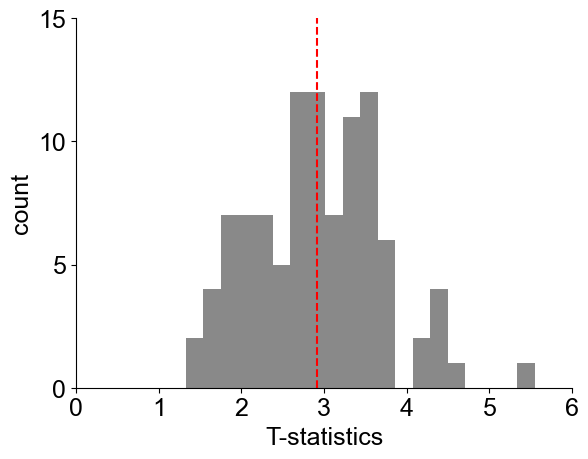

In [97]:
print(np.max(T_list))
fig, ax = plt.subplots()
plt.hist(np.array(T_list), bins=20, color='#898989')
plt.xlim(0, 6)
plt.axvline(np.mean(T_list), linestyle='--', color='r')
plt.xlabel('T-statistics', fontsize =font_sz)
plt.yticks([0, 5, 10, 15])
plt.ylabel('count', fontsize =font_sz)
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(figdir + 'SuppFig4_Thist.png', bbox_inches='tight')

plt.show()

In [100]:
8.1+8.1+4.9+4.9+1.9+23.25

51.15

In [101]:
2.99+22.5+11.22

36.71

In [102]:
127.31 + 110.95 + 138.6

376.86

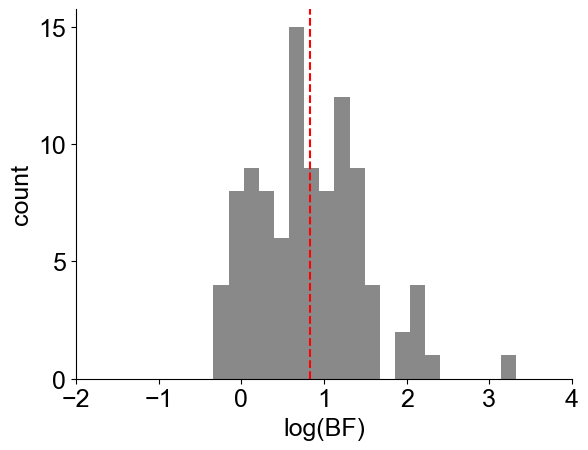

0.8270215707801399
0.46


In [98]:

fig, ax = plt.subplots()
plt.hist(np.log10(np.array(BF_mean_list)), bins=20, color='#898989')
plt.xlim(-2, 4)
plt.axvline(np.mean(np.log10(BF_mean_list)), linestyle='--', color='r')
plt.xlabel('log(BF)', fontsize =font_sz)
plt.yticks([0, 5, 10, 15])
plt.ylabel('count', fontsize =font_sz)
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(figdir + 'SuppFig4_BFhist.png', bbox_inches='tight')

plt.show()

print(np.mean(np.log10(BF_mean_list)))
print(np.min(BF_mean_list))

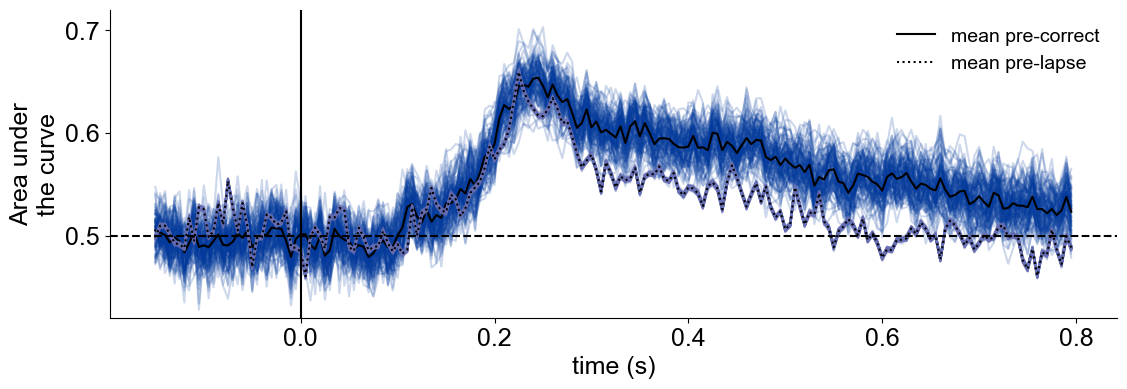

In [85]:
# plt.plot(mean_auc_in_all)
fig, ax= plt.subplots(figsize=(13, 4))
ct = 0
mean_auc_in_all.shape
for ind, row in pd.DataFrame(mean_auc_in_all).iterrows():
    plt.plot(epochs.times, row, c=blue_color, alpha=0.2)
plt.plot(epochs.times, np.mean(mean_auc_in_all, axis=0), 'black', label='mean pre-correct')
for ind, row in pd.DataFrame(mean_auc_out_all).iterrows():
    plt.plot(epochs.times, row, c=lightblue_color, alpha=0.2)
plt.plot(epochs.times, np.mean(mean_auc_out_all, axis=0), 'black', linestyle=':', label='mean pre-lapse')
plt.axhline(0.5,color='k', linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0.42, 0.72)
ax.set_yticks([0.5, 0.6, 0.7])
ax.axvline(0, color="k", linestyle="-")
ax.legend(frameon=False, framealpha=0)
ax.set_ylabel("Area under\nthe curve", fontsize=font_sz)  # Area Under the Curve
ax.set_xlabel('time (s)',fontsize=font_sz)
#xtick_inds = [0, 20, 40, 60, 80, 100, 120, 140]
# ax.set_xticks(xtick_inds)
# xlabs = epochs.times[epochs.times>0.0]
# xlabels = xlabs[xtick_inds]
# xlabels_round = [round(x, 3) for x in xlabels]
# ax.set_xticklabels(xlabels_round)
plt.savefig(figdir + 'SuppFig4_timecourse_balancedtrials.png', bbox_inches='tight')
plt.show()